# A/B Testing: Perbandingan Performa Model A vs Model B

Notebook ini mengimplementasikan **uji hipotesis dua proporsi (two-sample z-test)** untuk membandingkan akurasi dua model klasifikasi gambar sampah.

---

**Hipotesis:**
- $H_0$: Tidak ada perbedaan akurasi antara Model A dan Model B $(p_A = p_B)$
- $H_1$: Ada perbedaan akurasi antara Model A dan Model B $(p_A \neq p_B)$

## 1. Import Library

In [ ]:
import math
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

## 2. Load Data

In [ ]:
df = pd.read_csv('/content/inferensi_hasil.csv')

# Konversi kolom Hasil ke binary (1 = Benar, 0 = Salah)
df['converted_A'] = (df['Hasil_A'] == 'Benar').astype(int)
df['converted_B'] = (df['Hasil_B'] == 'Benar').astype(int)

print(f'Jumlah sampel  : {len(df)}')
print(f'Kolom          : {df.columns.tolist()}')
print()
print('Distribusi kelas (True_Label):')
print(df['True_Label'].value_counts())
df.head()

Jumlah sampel  : 300
Kolom          : ['No', 'Image', 'True_Label', 'Pred_Model_A', 'Conf_A (%)', 'Hasil_A', 'Pred_Model_B', 'Conf_B (%)', 'Hasil_B', 'converted_A', 'converted_B']

Distribusi kelas (True_Label):
True_Label
Kaca       50
Kardus     50
Kertas     50
Logam      50
Plastik    50
Residu     50
Name: count, dtype: int64


,No,Image,True_Label,Pred_Model_A,Conf_A (%),Hasil_A,Pred_Model_B,Conf_B (%),Hasil_B,converted_A,converted_B
0,1,R_5614.jpg,Kaca,Kaca,100.00,Benar,Kaca,100.00,Benar,1,1
1,2,R_5518.jpg,Kaca,Kaca,82.01,Benar,Kaca,99.92,Benar,1,1
2,3,R_5270.jpg,Kaca,Kaca,94.74,Benar,Kaca,98.66,Benar,1,1
3,4,R_5541.jpg,Kaca,Kaca,90.81,Benar,Kaca,99.91,Benar,1,1
4,5,R_5711.jpg,Kaca,Kaca,99.97,Benar,Kaca,97.80,Benar,1,1


## 3. Menghitung Metrik Proporsi

Untuk setiap model, kita hitung:
- **n**: total sampel
- **x**: jumlah prediksi benar
- **p**: proporsi / akurasi

In [ ]:
@dataclass
class MetricsEstimation:
    n: int
    x: int
    p: float

    def __repr__(self):
        return f'MetricsEstimation(n={self.n}, x={self.x}, p={self.p:.4f})'


def generate_proportion_metrics(data: pd.Series) -> MetricsEstimation:
    """
    Menghitung metrik proporsi dari data biner.

    Parameters:
    - data (pd.Series): Series biner (0/1).

    Returns:
    - MetricsEstimation: objek berisi n, x, dan p.
    """
    n = len(data)
    x = int(data.sum())
    p = data.mean()
    return MetricsEstimation(n=n, x=x, p=p)


metrics_A = generate_proportion_metrics(df['converted_A'])
metrics_B = generate_proportion_metrics(df['converted_B'])

print(f'Model A: {metrics_A}')
print(f'Model B: {metrics_B}')

Model A: MetricsEstimation(n=300, x=283, p=0.9433)
Model B: MetricsEstimation(n=300, x=269, p=0.8967)


## 4. Menghitung Proporsi Gabungan

Proporsi gabungan ($\hat{p}$) digunakan sebagai estimasi proporsi di bawah asumsi $H_0$:

$$\hat{p} = \frac{x_A + x_B}{n_A + n_B}$$

In [ ]:
def compute_pooled_proportion(m1: MetricsEstimation, m2: MetricsEstimation) -> float:
    """
    Menghitung proporsi gabungan dari dua sampel.

    Parameters:
    - m1, m2 (MetricsEstimation): Metrik dari masing-masing kelompok.

    Returns:
    - float: proporsi gabungan.
    """
    return (m1.x + m2.x) / (m1.n + m2.n)


p_hat = compute_pooled_proportion(metrics_A, metrics_B)
print(f'Proporsi gabungan (p_hat): {p_hat:.4f}')

Proporsi gabungan (p_hat): 0.9200


## 5. Menghitung Z-Statistic

Rumus z-test untuk dua proporsi:

$$z = \frac{\hat{p}_A - \hat{p}_B}{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_A} + \frac{1}{n_B}\right)}}$$

In [ ]:
def z_statistic_diff_proportions(m1: MetricsEstimation, m2: MetricsEstimation) -> float:
    """
    Menghitung z-statistic untuk perbedaan dua proporsi.

    Parameters:
    - m1, m2 (MetricsEstimation): Metrik dari masing-masing kelompok.

    Returns:
    - float: nilai z-statistic.
    """
    p_hat = compute_pooled_proportion(m1, m2)
    numerator = m1.p - m2.p
    denominator = np.sqrt(p_hat * (1 - p_hat) * (1/m1.n + 1/m2.n))
    return numerator / denominator


z = z_statistic_diff_proportions(metrics_A, metrics_B)
print(f'Z-statistic: {z:.4f}')

Z-statistic: 2.1068


## 6. Menolak / Menerima Hipotesis Nol

P-value dihitung menggunakan:

$$p\text{-value} = 2 \times (1 - \text{CDF}(|z|))$$

Jika $p\text{-value} < \alpha$, maka $H_0$ **ditolak**.

In [ ]:
def reject_null_hypothesis(z_statistic: float, alpha: float = 0.05) -> tuple:
    """
    Menentukan apakah hipotesis nol ditolak.

    Parameters:
    - z_statistic (float): Nilai z dari uji proporsi.
    - alpha (float): Tingkat signifikansi (default 0.05).

    Returns:
    - (bool, float): (reject, p_value)
    """
    p_value = 2 * (1 - stats.norm.cdf(abs(z_statistic)))
    reject = p_value < alpha
    return reject, p_value


alpha = 0.05
reject, p_value = reject_null_hypothesis(z, alpha)

print(f'Z-statistic  : {z:.4f}')
print(f'P-value      : {p_value:.6f}')
print(f'Alpha        : {alpha}')
print()
keputusan = 'DITOLAK' if reject else 'GAGAL DITOLAK'
print(f'Keputusan    : H\u2080 {keputusan}')
print()
if reject:
    print('Ada cukup bukti statistik untuk menyatakan perbedaan akurasi yang signifikan.')
else:
    print('Tidak cukup bukti statistik untuk menyatakan perbedaan akurasi yang signifikan.')

Z-statistic  : 2.1068
P-value      : 0.035139
Alpha        : 0.05

Keputusan    : H₀ DITOLAK

Ada cukup bukti statistik untuk menyatakan perbedaan akurasi yang signifikan.


## 7. Confidence Interval untuk Selisih Proporsi

$$\text{CI} = (\hat{p}_A - \hat{p}_B) \pm z_{1-\alpha/2} \cdot \sqrt{\frac{\hat{p}_A(1-\hat{p}_A)}{n_A} + \frac{\hat{p}_B(1-\hat{p}_B)}{n_B}}$$

In [ ]:
def confidence_interval_diff(m1: MetricsEstimation, m2: MetricsEstimation, alpha: float = 0.05) -> tuple:
    """
    Menghitung confidence interval untuk selisih dua proporsi.

    Returns:
    - (diff, ci_low, ci_high): selisih dan batas CI.
    """
    diff = m1.p - m2.p
    se = np.sqrt(m1.p*(1-m1.p)/m1.n + m2.p*(1-m2.p)/m2.n)
    z_crit = stats.norm.ppf(1 - alpha/2)
    ci_low = diff - z_crit * se
    ci_high = diff + z_crit * se
    return diff, ci_low, ci_high


diff, ci_low, ci_high = confidence_interval_diff(metrics_A, metrics_B)

print(f'Selisih proporsi (A - B) : {diff:.4f} ({diff*100:.2f}%)')
print(f'95% Confidence Interval  : ({ci_low*100:.2f}%, {ci_high*100:.2f}%)')
print()
if ci_low < 0 < ci_high:
    print('CI mencakup nol -> perbedaan tidak signifikan pada \u03b1 = 0.05')
else:
    print('CI tidak mencakup nol -> perbedaan signifikan pada \u03b1 = 0.05')

Selisih proporsi (A - B) : 0.0467 (4.67%)
95% Confidence Interval  : (0.34%, 8.99%)

CI tidak mencakup nol -> perbedaan signifikan pada α = 0.05


## 8. Analisis Per Kelas

In [ ]:
per_class = []
for label in sorted(df['True_Label'].unique()):
    sub = df[df['True_Label'] == label]
    acc_a = sub['converted_A'].mean() * 100
    acc_b = sub['converted_B'].mean() * 100
    per_class.append({'Kelas': label, 'n': len(sub),
                      'Akurasi Model A (%)': round(acc_a, 2),
                      'Akurasi Model B (%)': round(acc_b, 2),
                      'Selisih (A-B)': round(acc_a - acc_b, 2)})

df_class = pd.DataFrame(per_class)
print(df_class.to_string(index=False))

  Kelas  n  Akurasi Model A (%)  Akurasi Model B (%)  Selisih (A-B)
   Kaca 50                100.0                 86.0           14.0
 Kardus 50                 98.0                 86.0           12.0
 Kertas 50                100.0                 92.0            8.0
  Logam 50                 96.0                 94.0            2.0
Plastik 50                 80.0                 84.0           -4.0
 Residu 50                 92.0                 96.0           -4.0


## 9. Estimasi Sampel yang Dibutuhkan

Berapa sampel yang dibutuhkan agar perbedaan 7% ini bisa signifikan secara statistik?

In [ ]:
def estimate_sample_size_proportions(p1: float, p2: float,
                                     alpha: float = 0.05, beta: float = 0.20,
                                     two_sided: bool = True) -> int:
    """
    Menghitung ukuran sampel minimum untuk mendeteksi perbedaan dua proporsi.

    Parameters:
    - p1, p2 (float): Proporsi kedua kelompok.
    - alpha (float): Tingkat signifikansi.
    - beta (float): Probabilitas error tipe II (power = 1 - beta).
    - two_sided (bool): Uji dua sisi.

    Returns:
    - int: Ukuran sampel minimum per kelompok.
    """
    k = 1
    q1 = 1 - p1
    q2 = 1 - p2
    p_bar = (p1 + k * p2) / (1 + k)
    q_bar = 1 - p_bar
    delta = abs(p2 - p1)

    if two_sided:
        alpha = alpha / 2

    z_alpha = stats.norm.ppf(1 - alpha)
    z_beta  = stats.norm.ppf(1 - beta)

    n = (np.sqrt(p_bar * q_bar * (1 + 1/k)) * z_alpha +
         np.sqrt(p1 * q1 + p2 * q2 / k) * z_beta) ** 2 / delta ** 2
    return math.ceil(n)


n_needed = estimate_sample_size_proportions(metrics_B.p, metrics_A.p)
print(f'Proporsi Model A : {metrics_A.p:.4f}')
print(f'Proporsi Model B : {metrics_B.p:.4f}')
print()
print(f'Sampel minimum per model yang dibutuhkan: {n_needed}')
print(f'(saat ini hanya ada {metrics_A.n} sampel per model)')

Proporsi Model A : 0.9433
Proporsi Model B : 0.8967

Sampel minimum per model yang dibutuhkan: 530
(saat ini hanya ada 300 sampel per model)


## 10. Visualisasi Hasil

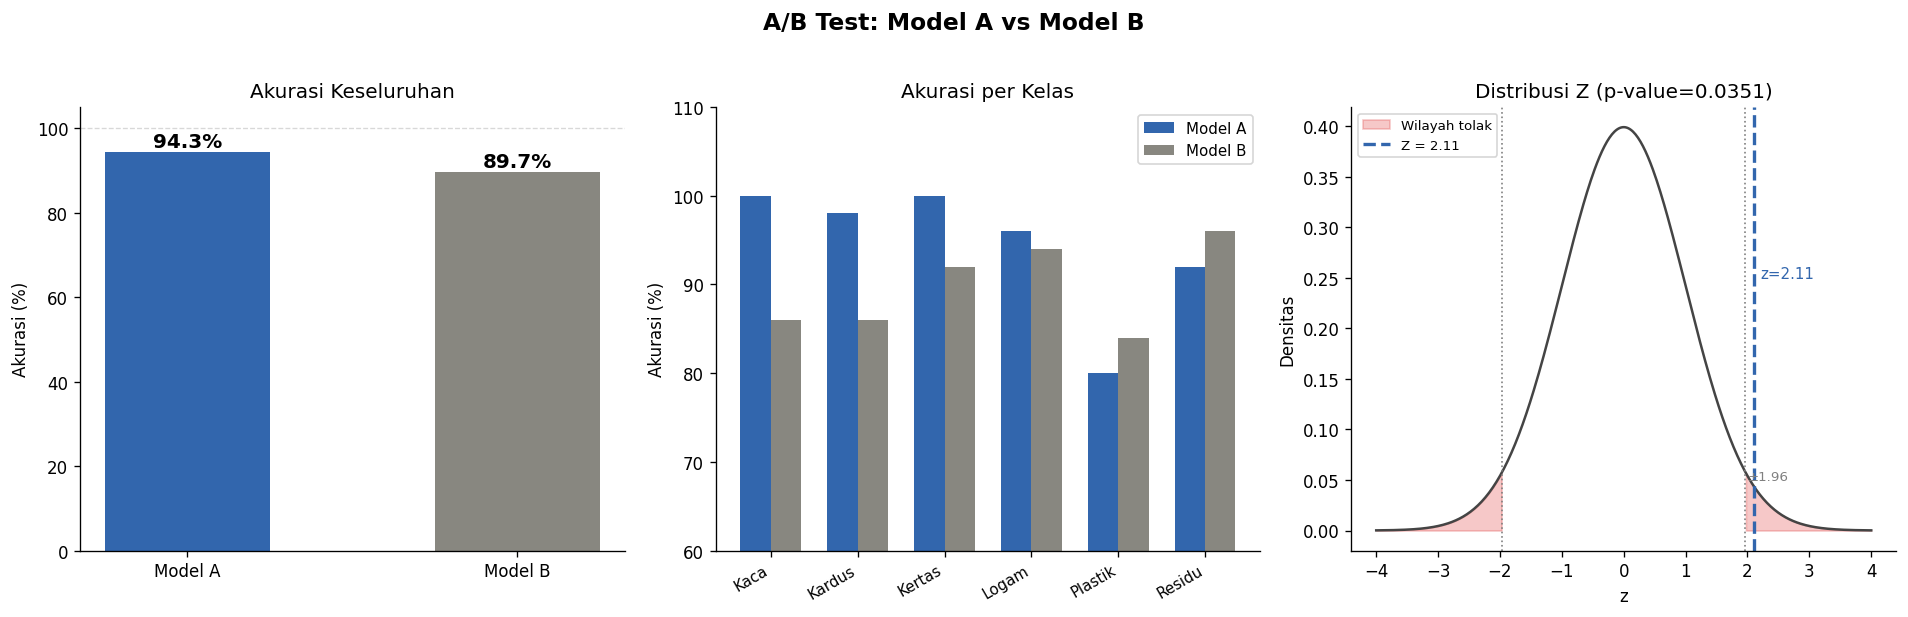

Plot tersimpan sebagai ab_test_result.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('A/B Test: Model A vs Model B', fontsize=14, fontweight='bold', y=1.02)

COLOR_A = '#3266ad'
COLOR_B = '#888780'

# --- Plot 1: Overall Accuracy ---
ax1 = axes[0]
bars = ax1.bar(['Model A', 'Model B'],
               [metrics_A.p * 100, metrics_B.p * 100],
               color=[COLOR_A, COLOR_B], width=0.5, edgecolor='none')
for bar, val in zip(bars, [metrics_A.p, metrics_B.p]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.set_ylabel('Akurasi (%)')
ax1.set_title('Akurasi Keseluruhan')
ax1.spines[['top', 'right']].set_visible(False)
ax1.axhline(y=100, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

# --- Plot 2: Per-class Accuracy ---
ax2 = axes[1]
classes = df_class['Kelas'].tolist()
acc_a_vals = df_class['Akurasi Model A (%)'].tolist()
acc_b_vals = df_class['Akurasi Model B (%)'].tolist()
x = np.arange(len(classes))
w = 0.35
ax2.bar(x - w/2, acc_a_vals, w, color=COLOR_A, label='Model A', edgecolor='none')
ax2.bar(x + w/2, acc_b_vals, w, color=COLOR_B, label='Model B', edgecolor='none')
ax2.set_xticks(x)
ax2.set_xticklabels(classes, rotation=30, ha='right', fontsize=9)
ax2.set_ylim(60, 110)
ax2.set_ylabel('Akurasi (%)')
ax2.set_title('Akurasi per Kelas')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

# --- Plot 3: Distribusi Z di bawah H0 ---
ax3 = axes[2]
x_range = np.linspace(-4, 4, 400)
y_norm = stats.norm.pdf(x_range)
ax3.plot(x_range, y_norm, color='#444', linewidth=1.5)

z_crit = stats.norm.ppf(0.975)
# Rejection regions
x_left  = x_range[x_range <= -z_crit]
x_right = x_range[x_range >= z_crit]
ax3.fill_between(x_left,  stats.norm.pdf(x_left),  color='#e24b4a', alpha=0.3, label='Wilayah tolak')
ax3.fill_between(x_right, stats.norm.pdf(x_right), color='#e24b4a', alpha=0.3)

ax3.axvline(x=z, color=COLOR_A, linewidth=2, linestyle='--', label=f'Z = {z:.2f}')
ax3.axvline(x= z_crit, color='gray', linewidth=1, linestyle=':')
ax3.axvline(x=-z_crit, color='gray', linewidth=1, linestyle=':')
ax3.text(z + 0.1, 0.25, f'z={z:.2f}', color=COLOR_A, fontsize=9)
ax3.text( z_crit + 0.05, 0.05, f'±{z_crit:.2f}', color='gray', fontsize=8)
ax3.set_title(f'Distribusi Z (p-value={p_value:.4f})')
ax3.set_xlabel('z')
ax3.set_ylabel('Densitas')
ax3.legend(fontsize=8)
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('ab_test_result.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot tersimpan sebagai ab_test_result.png')

## 11. Ringkasan Hasil

In [ ]:
print('=' * 55)
print('       RINGKASAN HASIL A/B TEST')
print('=' * 55)
print(f'  Model A  ->  n={metrics_A.n}, benar={metrics_A.x}, akurasi={metrics_A.p*100:.1f}%')
print(f'  Model B  ->  n={metrics_B.n}, benar={metrics_B.x}, akurasi={metrics_B.p*100:.1f}%')
print(f'  Selisih  ->  {diff*100:+.1f}% (A lebih tinggi)')
print('-' * 55)
print(f'  Z-statistic : {z:.4f}')
print(f'  P-value     : {p_value:.6f}')
print(f'  Alpha       : {alpha}')
print(f'  95% CI      : ({ci_low*100:.2f}%, {ci_high*100:.2f}%)')
print('-' * 55)
print(f'  Keputusan   : H\u2080 {keputusan}')
print()
if not reject:
    print(f'  Perbedaan 7% TIDAK signifikan secara statistik.')
    print(f'  Sampel minimum yang dibutuhkan: {n_needed} per model')
    print(f'  (saat ini hanya {metrics_A.n} per model)')
else:
    print(f'  Perbedaan akurasi SIGNIFIKAN secara statistik.')
    print(f'  Model A direkomendasikan untuk deployment.')
print('=' * 55)

       RINGKASAN HASIL A/B TEST
  Model A  ->  n=300, benar=283, akurasi=94.3%
  Model B  ->  n=300, benar=269, akurasi=89.7%
  Selisih  ->  +4.7% (A lebih tinggi)
-------------------------------------------------------
  Z-statistic : 2.1068
  P-value     : 0.035139
  Alpha       : 0.05
  95% CI      : (0.34%, 8.99%)
-------------------------------------------------------
  Keputusan   : H₀ DITOLAK

  Perbedaan akurasi SIGNIFIKAN secara statistik.
  Model A direkomendasikan untuk deployment.
